Kết nối thành công!


C:\Users\admin\AppData\Local\Temp\ipykernel_24872\563815374.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=conn)


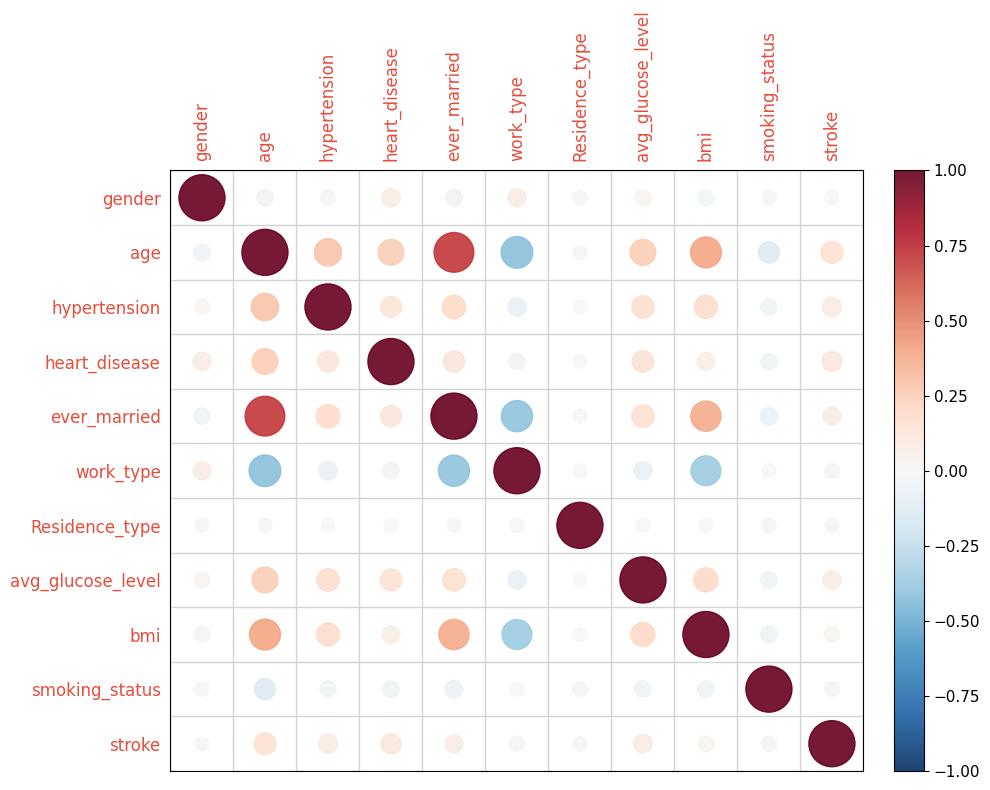


--- MỨC ĐỘ TƯƠNG QUAN VỚI BIẾN 'STROKE' ---
age                  0.151684
heart_disease        0.109678
hypertension         0.085831
avg_glucose_level    0.079384
ever_married         0.071713
bmi                  0.024108
gender               0.004928
Residence_type       0.001621
work_type           -0.019690
smoking_status      -0.020862
Name: stroke, dtype: float64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import psycopg2

# 1. ĐỌC VÀ CHUẨN BỊ DỮ LIỆU
conn = psycopg2.connect(
        host="116.111.122.217",
        database="appdb",
        user="group_5",
        password="group_5",
        port="5432"  # mặc định là 5432
    )
    
print("Kết nối thành công!")

query = """SELECT * FROM "stroke_data";"""
df = pd.read_sql(query, con=conn)

# Tạo bản sao để không làm ảnh hưởng dữ liệu gốc
df_encoded = df.copy()

# Xóa cột 'id' nếu có vì không dùng để tính tương quan
if 'id' in df_encoded.columns:
    df_encoded.drop('id', axis=1, inplace=True)

# Mã hóa các cột dạng text sang số (Label Encoding)
cat_columns = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
le = LabelEncoder()
for col in cat_columns:
    if col in df_encoded.columns:
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# 2. TÍNH MA TRẬN TƯƠNG QUAN
corr_matrix = df_encoded.corr()

# 3. VẼ BIỂU ĐỒ BONG BÓNG (BUBBLE CORRELATION MATRIX)
fig, ax = plt.subplots(figsize=(10, 8))

columns = corr_matrix.columns
n = len(columns)

# Lưới tọa độ cho các bong bóng
x, y = np.meshgrid(np.arange(n), np.arange(n))

# Làm phẳng ma trận tương quan để đưa vào đồ thị scatter
c = corr_matrix.values.flatten()
# Kích thước bong bóng tỷ lệ thuận với giá trị tuyệt đối của hệ số tương quan
size = np.abs(c) * 1000 +100

# Bản đồ màu (colormap): 'RdBu_r' là Reversed Red-Blue 
cmap = plt.get_cmap('RdBu_r')

# Vẽ các bong bóng
scatter = ax.scatter(x.flatten(), y.flatten(), s=size, c=c, cmap=cmap, vmin=-1, vmax=1, alpha=0.9)

# Định dạng trục tọa độ
ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))

# Đặt tên các trục
ax.set_xticklabels(columns, rotation=90, fontsize=12, color='#E74C3C')
ax.set_yticklabels(columns, fontsize=12, color='#E74C3C')
ax.xaxis.tick_top()
ax.invert_yaxis() # Đảo ngược trục y để đường chéo chính đi từ góc trên trái xuống dưới phải

# Tạo lưới ô vuông mờ phía sau
ax.set_xticks(np.arange(n+1)-0.5, minor=True)
ax.set_yticks(np.arange(n+1)-0.5, minor=True)
ax.grid(which="minor", color="lightgray", linestyle='-', linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False, top=False, right=False)
ax.tick_params(which="major", bottom=False, left=False, top=False, right=False)

# Thêm thanh màu (Colorbar)
cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=11)

plt.tight_layout()
plt.show()

# 4. IN RA TƯƠNG QUAN VỚI BIẾN STROKE
if 'stroke' in corr_matrix.columns:
    print("\n--- MỨC ĐỘ TƯƠNG QUAN VỚI BIẾN 'STROKE' ---")
    stroke_corr = corr_matrix['stroke'].drop('stroke').sort_values(ascending=False)
    print(stroke_corr)